In [ ]:
# 必要なライブラリのimport
import pandas as pd
import statsmodels.formula.api as smf
import seaborn as sns

In [3]:
# Pandasでデータを読み込み、その内容を何件か確認
data = pd.read_csv('iowa_ames_housing_revised.csv')

In [4]:
data.shape

(1460, 9)

In [5]:
data.head()

,Order,area,price,OverallQual,OverallCond,YearBuilt,BsmtFinSF1,X1stFlrSF,X2ndFlrSF
0,1,1710,208500,7,5,2003,706,856,854
1,2,1262,181500,6,8,1976,978,1262,0
2,3,1786,223500,7,5,2001,486,920,866
3,4,1717,140000,7,5,1915,216,961,756
4,5,2198,250000,8,5,2000,655,1145,1053


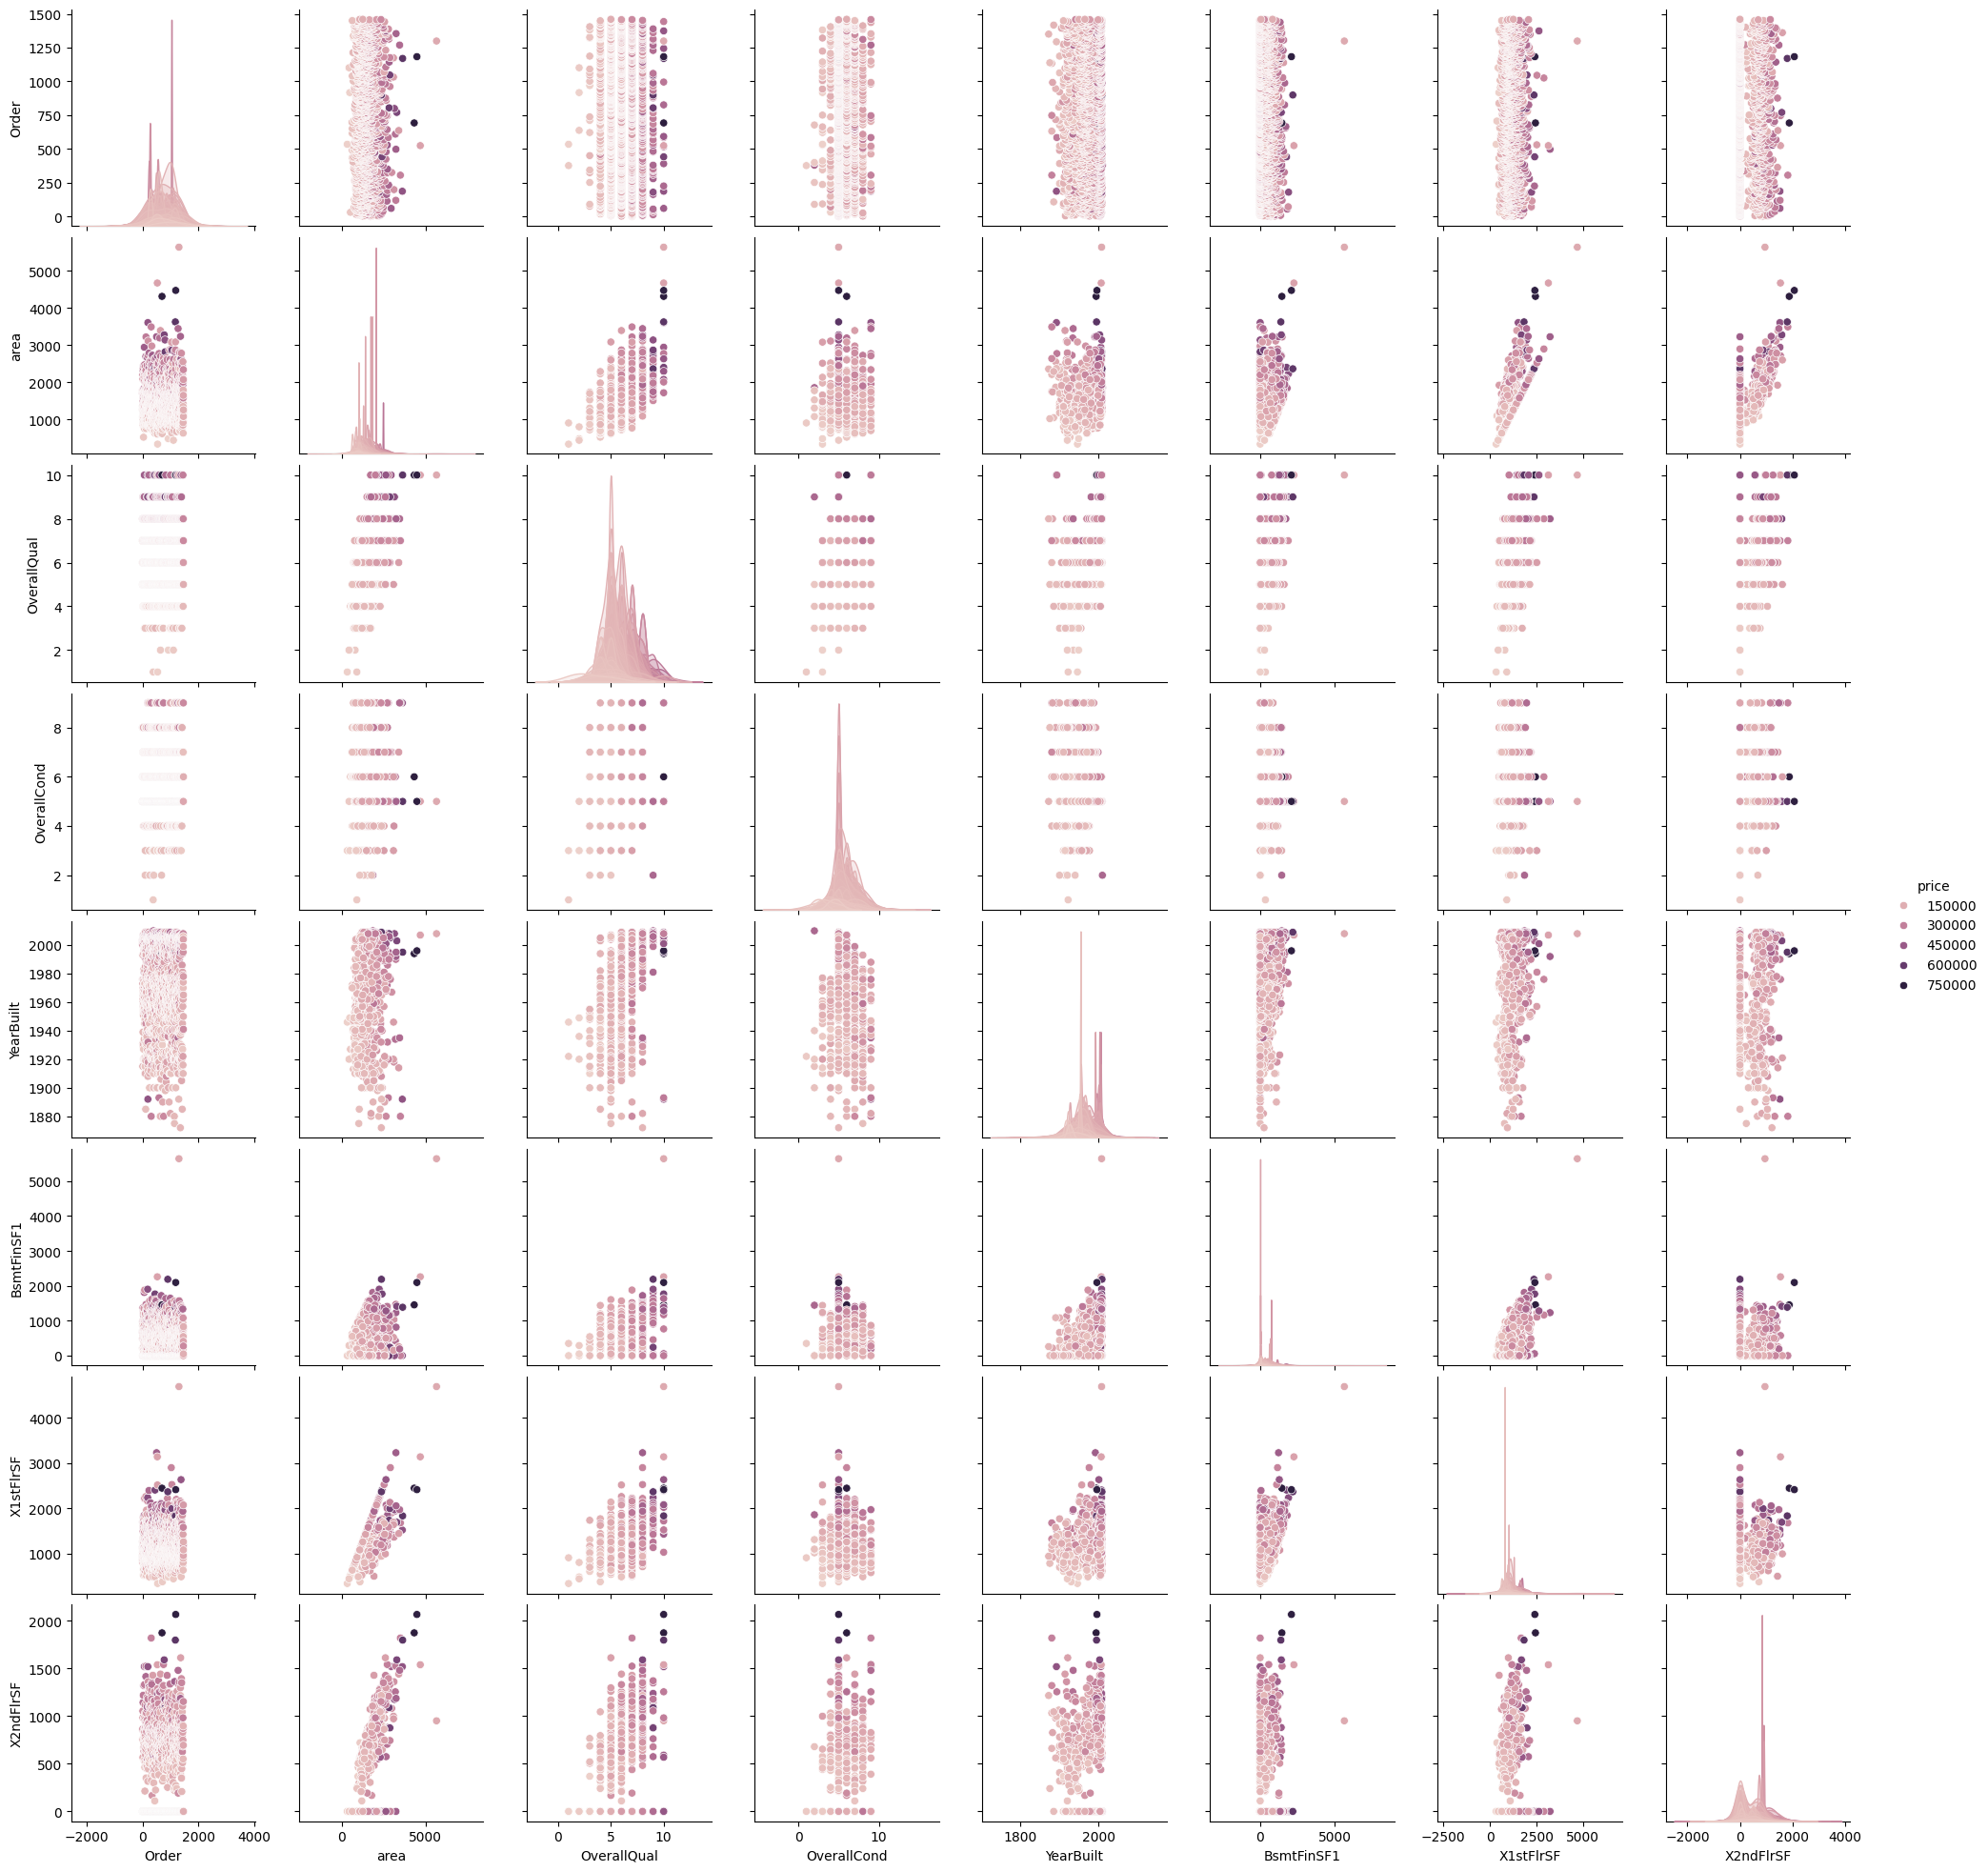

In [ ]:
# このデータのペアプロットを作成してください
sns.pairplot(data, hue='price')

In [9]:
# 最小二乗法の実施（説明変数：YearBuilt）
model1 = smf.ols(formula='price ~ YearBuilt', data=data).fit()

# 最小二乗法の実施（説明変数：OverallQual + X1stFlrSF）
model2 = smf.ols(formula='price ~ OverallQual + X1stFlrSF', data=data).fit()

# 最小二乗法の実施（説明変数：YearBuilt + OverallQual + X1stFlrSF）
model3 = smf.ols(formula='price ~ YearBuilt + OverallQual + X1stFlrSF', data=data).fit()

In [10]:
# AICを計算する
print('Model-1:',model1.aic)
print('Model-2:',model2.aic)
print('Model-3:',model3.aic)

Model-1: 36625.70646748859
Model-2: 35367.18730733775
Model-3: 35336.629042057226


AICが小さいmodel3の詳細を表示する

In [11]:
# 詳細
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.700
Model:                            OLS   Adj. R-squared:                  0.700
Method:                 Least Squares   F-statistic:                     1134.
Date:                Mon, 06 Oct 2025   Prob (F-statistic):               0.00
Time:                        13:04:46   Log-Likelihood:                -17664.
No. Observations:                1460   AIC:                         3.534e+04
Df Residuals:                    1456   BIC:                         3.536e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept   -6.172e+05   8.74e+04     -7.065      

In [ ]:
# 興味本位の為、削除
# model4 = smf.ols(formula='price ~ YearBuilt + OverallQual + X1stFlrSF + OverallCond', data=data).fit()
# model5 = smf.ols(formula='price ~ YearBuilt + OverallQual + X1stFlrSF + OverallCond + BsmtFinSF1', data=data).fit()
# model6 = smf.ols(formula='price ~ YearBuilt + OverallQual + X1stFlrSF + OverallCond + BsmtFinSF1 + X2ndFlrSF', data=data).fit()
# model7 = smf.ols(formula='price ~ YearBuilt + OverallQual + X1stFlrSF + OverallCond + BsmtFinSF1 + X2ndFlrSF + area', data=data).fit()


In [ ]:
# 興味本位の為、削除
# print('Model-4:',model4.aic)
# print('Model-5:',model5.aic)
# print('Model-6:',model6.aic)
# print('Model-7:',model7.aic)

Model-4: 35319.34860416887
Model-5: 35277.126250643996
Model-6: 34926.199874739
Model-7: 34926.99822305726


In [ ]:
# 興味本位の為、削除
# import statsmodels.api as sm

# # 説明変数と目的変数を指定
# X = data[['area', 'OverallQual', 'OverallCond', 'YearBuilt', 'BsmtFinSF1', 'X1stFlrSF', 'X2ndFlrSF']]
# y = data['price']

# # 定数項を追加
# X = sm.add_constant(X)

# # OLSモデルの作成と学習
# model = sm.OLS(y, X).fit()

# # モデルの概要を表示
# print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.774
Method:                 Least Squares   F-statistic:                     714.0
Date:                Mon, 06 Oct 2025   Prob (F-statistic):               0.00
Time:                        13:16:48   Log-Likelihood:                -17455.
No. Observations:                1460   AIC:                         3.493e+04
Df Residuals:                    1452   BIC:                         3.497e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         -1.1e+06   9.03e+04    -12.174      